# EDA TEMPORAL

## Librerías

In [28]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import requests
from scipy import stats

## Datos

In [9]:
df_si = pd.read_csv('sell_in_suiza_geo.csv')
df_so = pd.read_csv('limpio/sell_out_suiza_v2.csv')

C:\Users\manue\AppData\Local\Temp\ipykernel_24904\1014752903.py:2: DtypeWarning: Columns (0: FSDCUSTOMERNAME, 1: FSDCUSTOMERFRIENDLYNAME, 2: ROLE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_so = pd.read_csv('limpio/sell_out_suiza_v2.csv')


## Formato

In [10]:
df_si['MONTH_DT'] = pd.to_datetime(df_si['MONTH_DT'])
df_so['MONTHDATE'] = pd.to_datetime(df_so['MONTHDATE'])

df_si['CUSTOMERLATITUDE'] = df_si['CUSTOMERLATITUDE'].str.replace(',', '.').astype(float)
df_si['CUSTOMERLONGITUDE'] = df_si['CUSTOMERLONGITUDE'].str.replace(',', '.').astype(float)
df_si['CUSTOMERPOSTALCODE'] = df_si['CUSTOMERPOSTALCODE'].dropna().astype(int)
df_so['POSTALCODE'] = df_so['POSTALCODE'].dropna().astype(int)

print('Sell In:', df_si.shape)
print('Sell Out:', df_so.shape)
print('Listo')

Sell In: (294132, 51)
Sell Out: (704699, 33)
Listo


## Temporalidad

### Volumen de Venta

##### Volumen de venta general

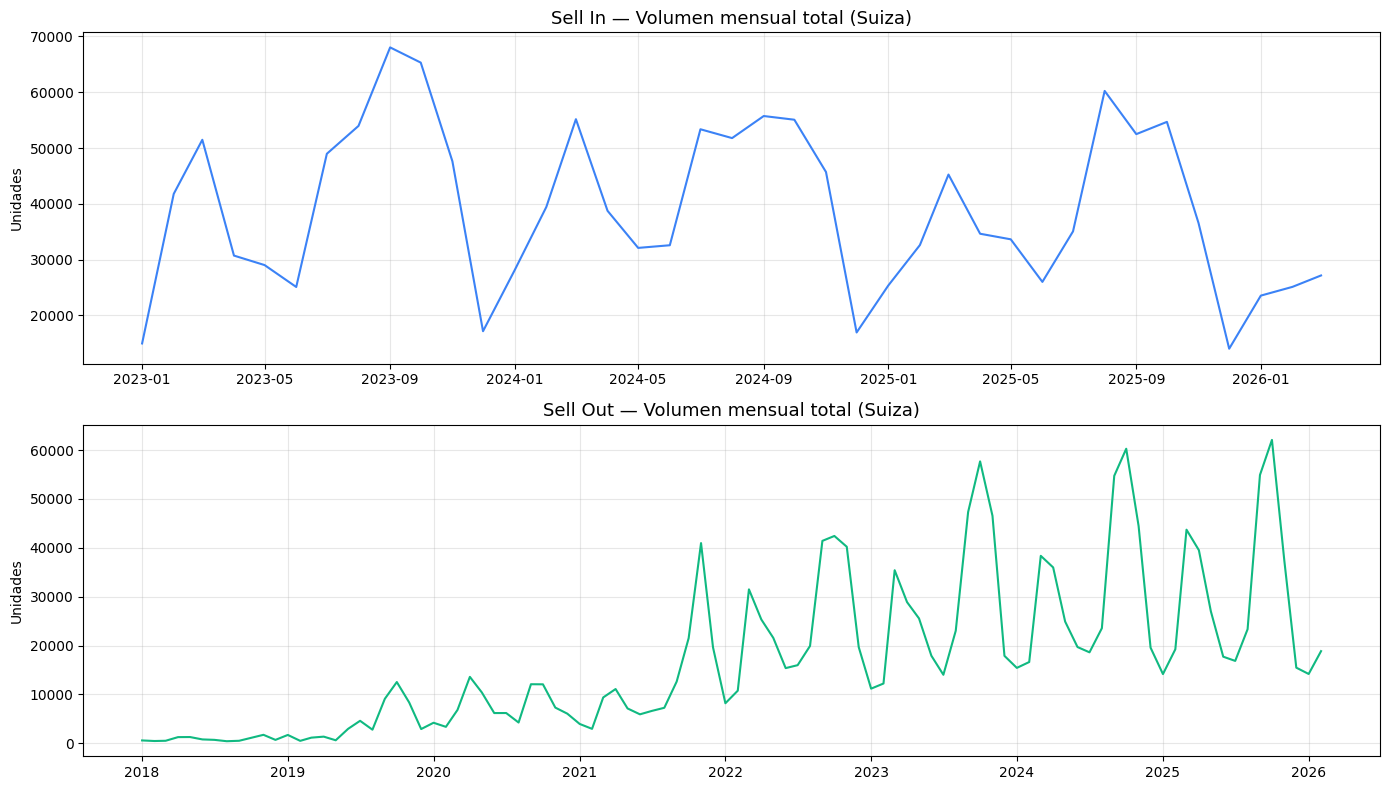

Gráfico guardado


In [11]:
si_mensual = df_si.groupby('MONTH_DT')['BILLED_QTY'].sum().reset_index()
so_mensual = df_so.groupby('MONTHDATE')['TOTALSELLOUTQTTY'].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Sell In
axes[0].plot(si_mensual['MONTH_DT'], si_mensual['BILLED_QTY'], 
             color='#3B82F6', linewidth=1.5)
axes[0].set_title('Sell In — Volumen mensual total (Suiza)', fontsize=13)
axes[0].set_ylabel('Unidades')
axes[0].grid(True, alpha=0.3)

# Sell Out
axes[1].plot(so_mensual['MONTHDATE'], so_mensual['TOTALSELLOUTQTTY'], 
             color='#10B981', linewidth=1.5)
axes[1].set_title('Sell Out — Volumen mensual total (Suiza)', fontsize=13)
axes[1].set_ylabel('Unidades')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_volumen_mensual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado')

##### Volumen de venta mensual

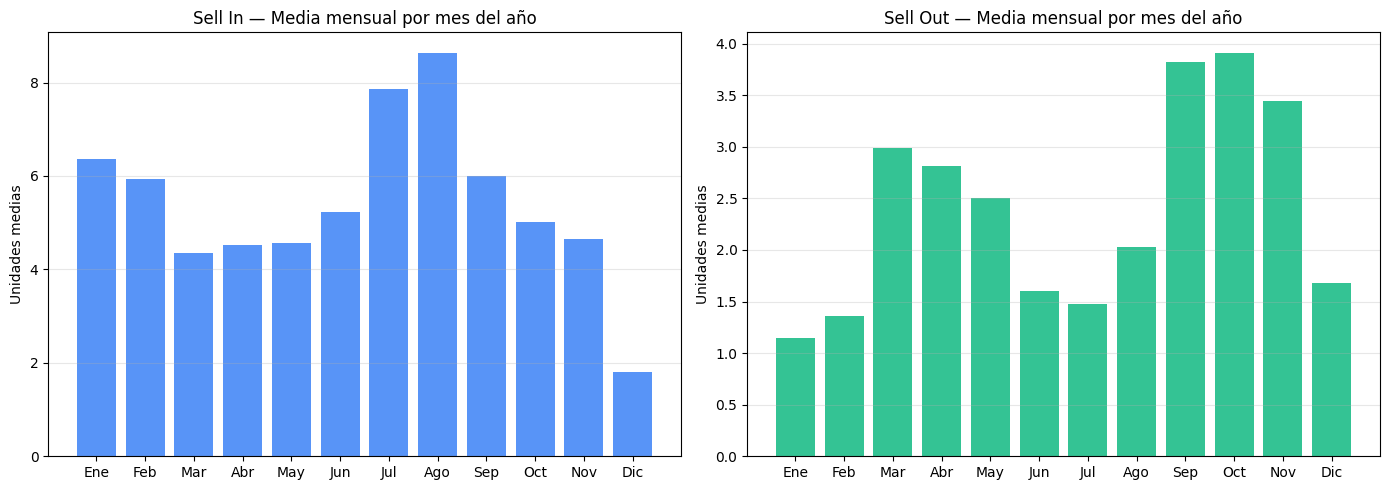

In [12]:
si_estacional = df_si.groupby(df_si['MONTH_DT'].dt.month)['BILLED_QTY'].mean()
so_estacional = df_so.groupby(df_so['MONTHDATE'].dt.month)['TOTALSELLOUTQTTY'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

axes[0].bar(range(1,13), si_estacional, color='#3B82F6', alpha=0.85)
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(meses)
axes[0].set_title('Sell In — Media mensual por mes del año')
axes[0].set_ylabel('Unidades medias')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(1,13), so_estacional, color='#10B981', alpha=0.85)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(meses)
axes[1].set_title('Sell Out — Media mensual por mes del año')
axes[1].set_ylabel('Unidades medias')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('temporal_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()

Desfase de dos meses entre que el pedido del distribuidor y venta al cliente final

### Desfase por temporada

#### Cuantificación del desfase

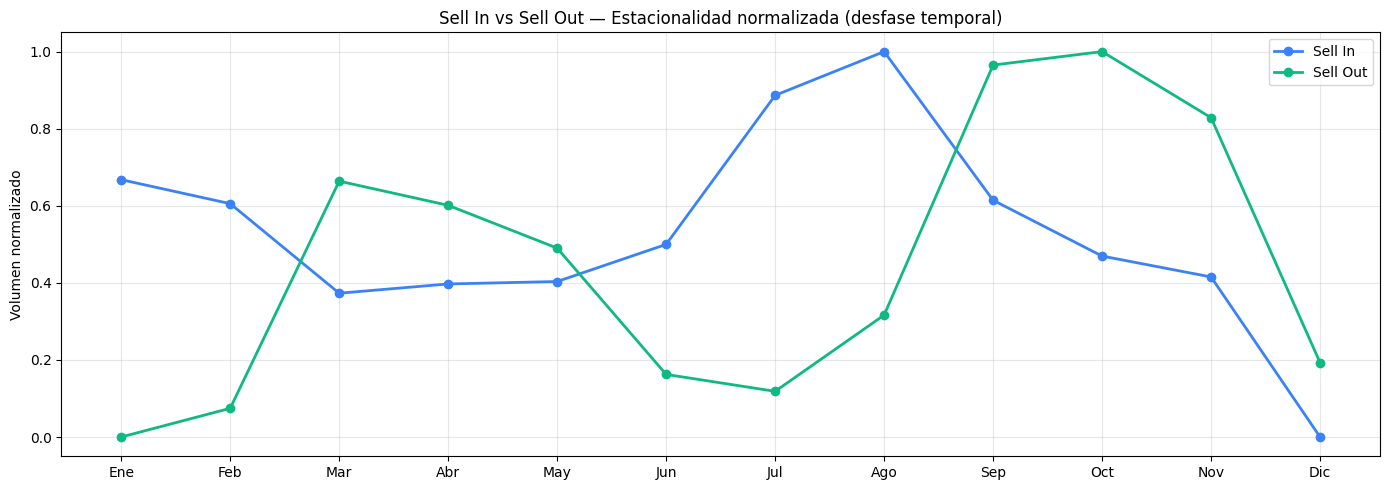

In [13]:
# Normalizar ambas series al mismo rango para comparar el desfase
si_norm = (si_estacional - si_estacional.min()) / (si_estacional.max() - si_estacional.min())
so_norm = (so_estacional - so_estacional.min()) / (so_estacional.max() - so_estacional.min())

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(range(1,13), si_norm, color='#3B82F6', linewidth=2, marker='o', label='Sell In')
ax.plot(range(1,13), so_norm, color='#10B981', linewidth=2, marker='o', label='Sell Out')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_title('Sell In vs Sell Out — Estacionalidad normalizada (desfase temporal)')
ax.set_ylabel('Volumen normalizado')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_desfase.png', dpi=150, bbox_inches='tight')
plt.show()

El sell_in se puede usar ccomo variable predictoria adelantada del sell-out, retardo de 2 meses

##### Consistencia del desfase

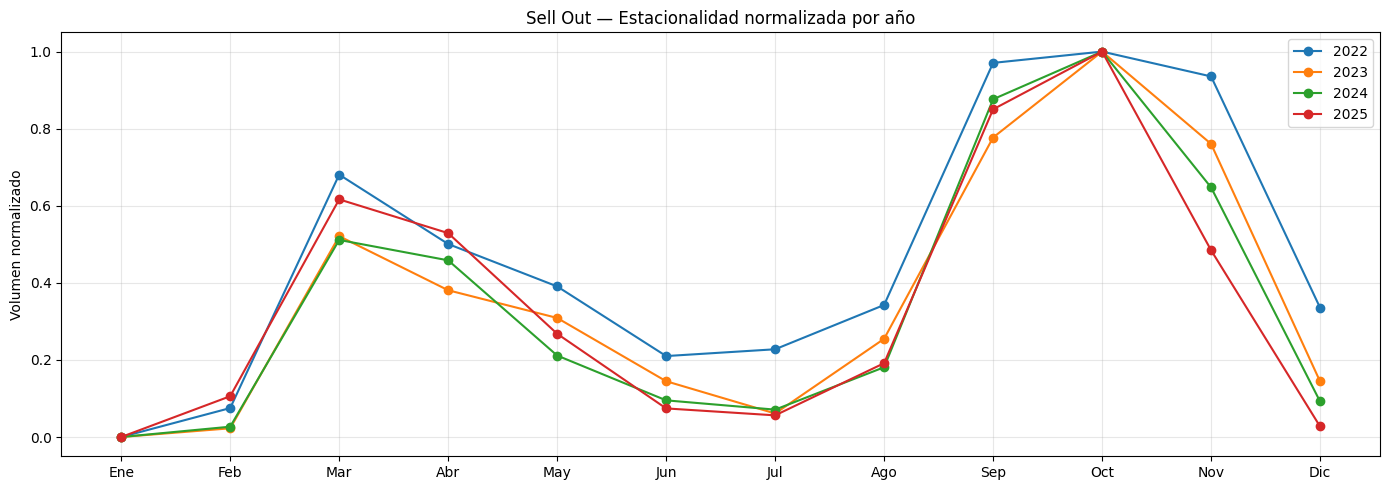

In [14]:
so_año_mes = df_so.groupby([df_so['MONTHDATE'].dt.year, 
                             df_so['MONTHDATE'].dt.month])['TOTALSELLOUTQTTY'].sum().unstack(0)

fig, ax = plt.subplots(figsize=(14, 5))

# Solo años con datos completos
for año in [2022, 2023, 2024, 2025]:
    if año in so_año_mes.columns:
        serie = so_año_mes[año]
        serie_norm = (serie - serie.min()) / (serie.max() - serie.min())
        ax.plot(range(1,13), serie_norm, marker='o', linewidth=1.5, label=str(año))

ax.set_xticks(range(1,13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_title('Sell Out — Estacionalidad normalizada por año')
ax.set_ylabel('Volumen normalizado')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_estacionalidad_años.png', dpi=150, bbox_inches='tight')
plt.show()

Dos estacionalidades claras

### Tipo de Neumático en cada estacionalidad

In [16]:
print(df_so['TIRESEASON'].value_counts())

TIRESEASON
Winter        338759
Summer        286720
All Season     64265
Name: count, dtype: int64


##### Volumen mensual por tipo

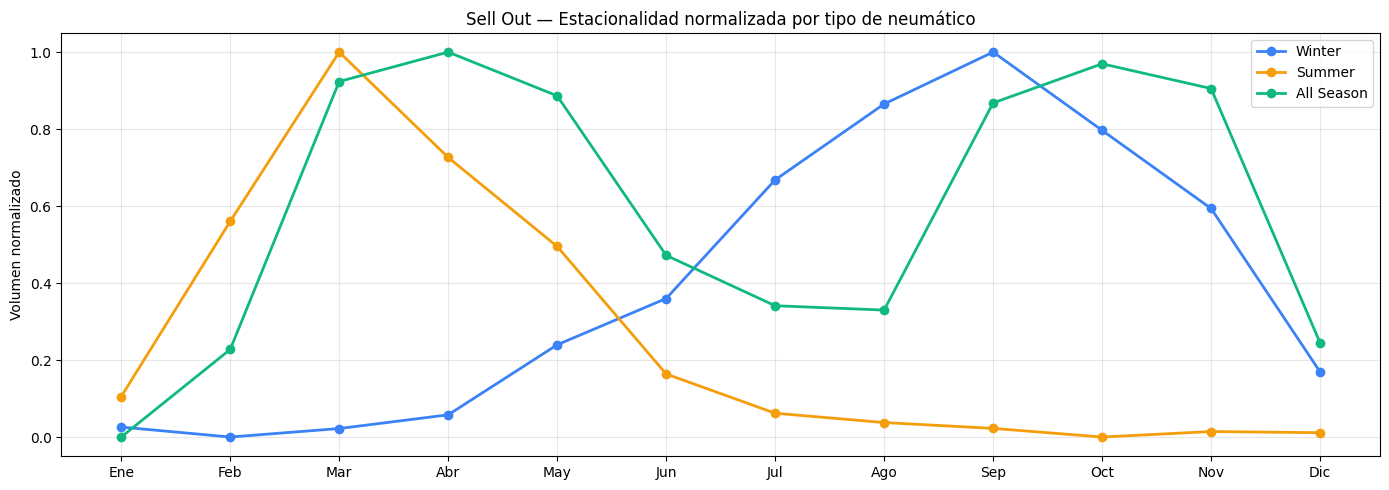

In [17]:
# Volumen mensual por tipo de neumático
so_tipo = df_so.groupby([df_so['MONTHDATE'].dt.month, 'TIRESEASON'])['TOTALSELLOUTQTTY'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 5))

colores = {'Winter': '#3B82F6', 'Summer': '#F59E0B', 'All Season': '#10B981'}
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

for tipo, color in colores.items():
    if tipo in so_tipo.columns:
        serie = so_tipo[tipo]
        serie_norm = (serie - serie.min()) / (serie.max() - serie.min())
        ax.plot(range(1,13), serie_norm, marker='o', linewidth=2, 
                color=color, label=tipo)

ax.set_xticks(range(1,13))
ax.set_xticklabels(meses)
ax.set_title('Sell Out — Estacionalidad normalizada por tipo de neumático')
ax.set_ylabel('Volumen normalizado')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_tipo_neumatico.png', dpi=150, bbox_inches='tight')
plt.show()

Los de winter y los de summer están asociados claramente a su estacionalidad, mientras que los de all season están presentes en ambas, esto puede deberse al coste del neumático y/o al costo de tener dos tipos de ruedas distintas. Ver en Eda geográfico

##### Volumen mensual por tipo absoluto 

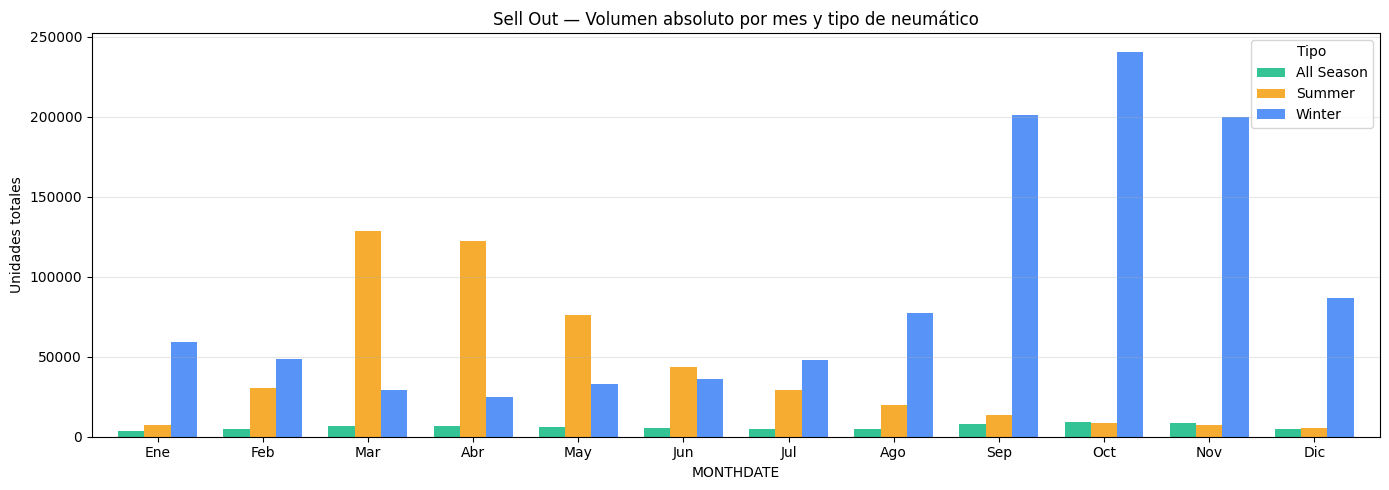

In [18]:
so_tipo_abs = df_so.groupby([df_so['MONTHDATE'].dt.month, 
                              'TIRESEASON'])['TOTALSELLOUTQTTY'].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 5))

so_tipo_abs.plot(kind='bar', ax=ax, color=['#10B981', '#F59E0B', '#3B82F6'], 
                 alpha=0.85, width=0.75)

ax.set_xticks(range(12))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'], rotation=0)
ax.set_title('Sell Out — Volumen absoluto por mes y tipo de neumático')
ax.set_ylabel('Unidades totales')
ax.legend(title='Tipo')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('temporal_tipo_absoluto.png', dpi=150, bbox_inches='tight')
plt.show()

### Influencia Climática

##### Obtención de datos climáticos (Open Meteo)

In [23]:
params = {
    "latitude": 47.3769,
    "longitude": 8.5417,
    "start_date": "2018-01-01",
    "end_date": "2026-02-28",
    "daily": "temperature_2m_mean,precipitation_sum,snowfall_sum",
    "timezone": "Europe/Zurich"
}

response = requests.get(url, params=params)
data = response.json()

# Convertir a dataframe
df_clima = pd.DataFrame({
    'fecha': pd.to_datetime(data['daily']['time']),
    'temp_media': data['daily']['temperature_2m_mean'],
    'precipitacion': data['daily']['precipitation_sum'],
    'nieve': data['daily']['snowfall_sum']
})

# Agregar a mensual
df_clima_mensual = df_clima.resample('MS', on='fecha').agg({
    'temp_media': 'mean',
    'precipitacion': 'sum',
    'nieve': 'sum'
}).reset_index()

print(df_clima_mensual.shape)
print(df_clima_mensual.head(12))

(98, 4)
        fecha  temp_media  precipitacion  nieve
0  2018-01-01    4.209677          154.1  12.81
1  2018-02-01   -1.107143           69.5  16.45
2  2018-03-01    3.606452           75.7   8.19
3  2018-04-01   12.123333           36.3   0.77
4  2018-05-01   15.096774           83.1   0.00
5  2018-06-01   18.376667           93.0   0.00
6  2018-07-01   21.696774           46.1   0.00
7  2018-08-01   21.593548           97.3   0.00
8  2018-09-01   16.913333           74.9   0.00
9  2018-10-01   11.267742           72.0   2.73
10 2018-11-01    5.323333           23.9   0.84
11 2018-12-01    3.335484          128.0   7.98


##### Cruce de datos con el Sell Out 

In [26]:
so_mensual_tipo = df_so.groupby([
    df_so['MONTHDATE'].dt.to_period('M').dt.to_timestamp(), 
    'TIRESEASON'])['TOTALSELLOUTQTTY'].sum().unstack().reset_index()
so_mensual_tipo.columns.name = None
so_mensual_tipo = so_mensual_tipo.rename(columns={'MONTHDATE': 'fecha'})

df_merged = so_mensual_tipo.merge(df_clima_mensual, on='fecha', how='inner')

print(df_merged.shape)
print(df_merged.head())

(98, 7)
       fecha  All Season  Summer  Winter  temp_media  precipitacion  nieve
0 2018-01-01        46.0    49.0   500.0    4.209677          154.1  12.81
1 2018-02-01        29.0    65.0   383.0   -1.107143           69.5  16.45
2 2018-03-01        38.0   227.0   261.0    3.606452           75.7   8.19
3 2018-04-01        40.0  1028.0   204.0   12.123333           36.3   0.77
4 2018-05-01        76.0  1051.0   163.0   15.096774           83.1   0.00


##### Correlación entre temperatura y ventas por tipo

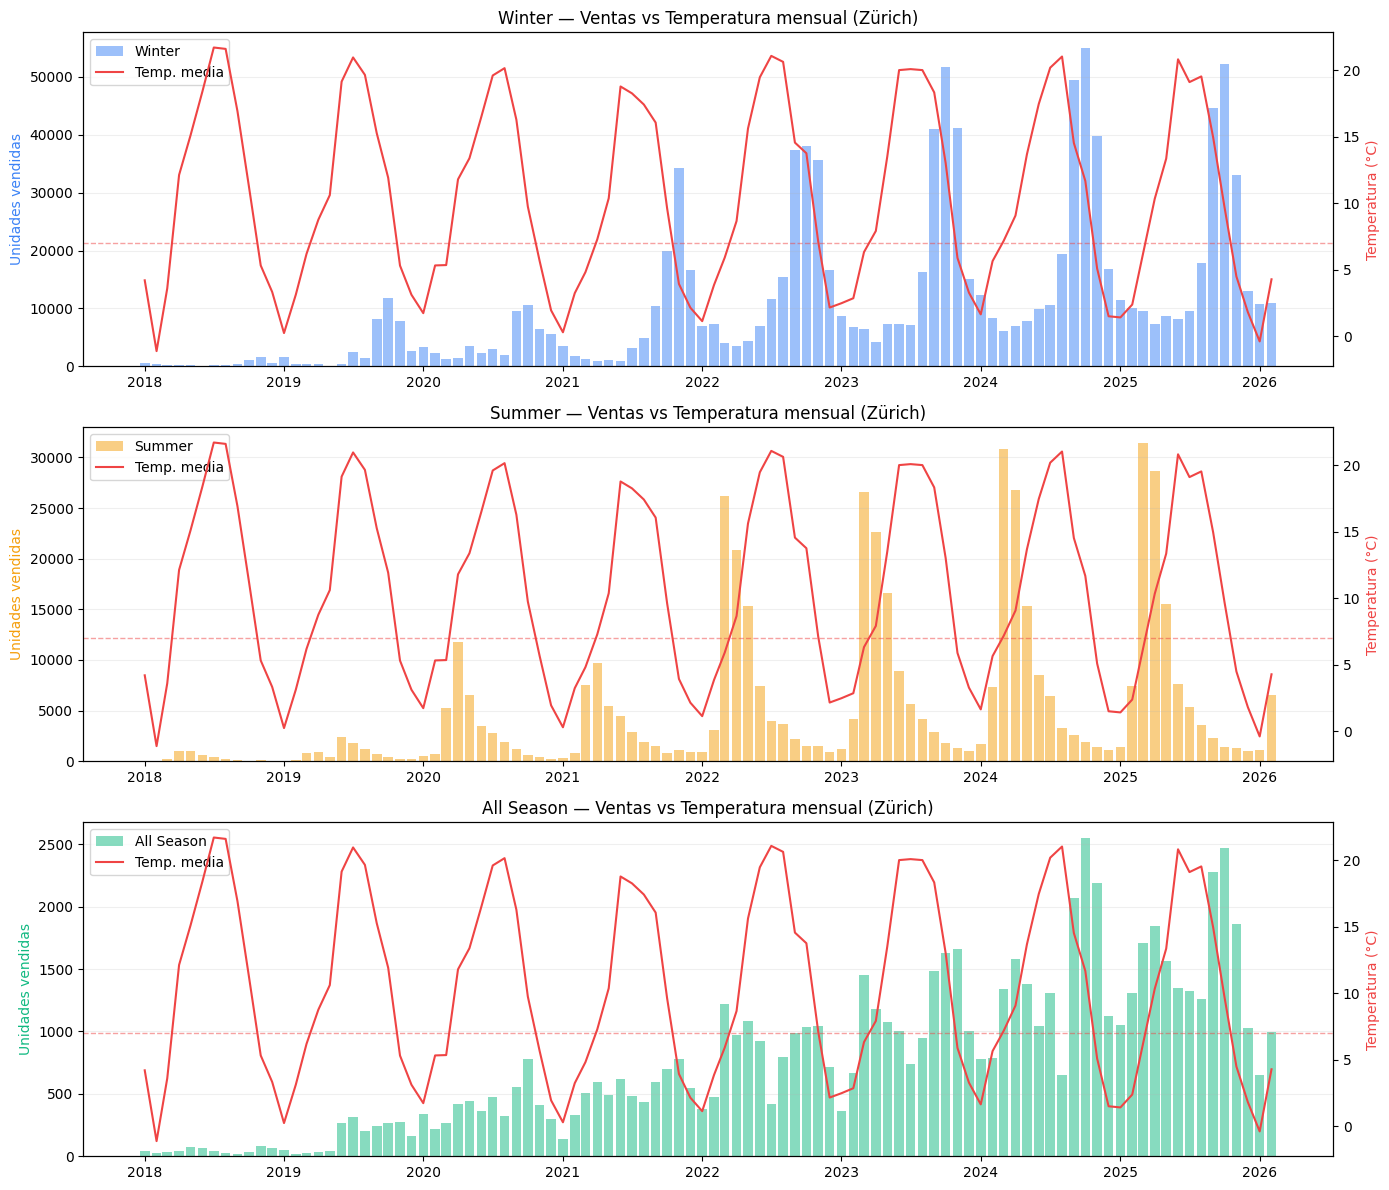

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

colores = {'Winter': '#3B82F6', 'Summer': '#F59E0B', 'All Season': '#10B981'}

for i, tipo in enumerate(['Winter', 'Summer', 'All Season']):
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    # Ventas
    ax1.bar(df_merged['fecha'], df_merged[tipo], 
            color=colores[tipo], alpha=0.5, label=tipo, width=25)
    ax1.set_ylabel('Unidades vendidas', color=colores[tipo])
    
    # Temperatura
    ax2.plot(df_merged['fecha'], df_merged['temp_media'], 
             color='#EF4444', linewidth=1.5, label='Temp. media')
    ax2.set_ylabel('Temperatura (°C)', color='#EF4444')
    ax2.axhline(y=7, color='#EF4444', linestyle='--', 
                alpha=0.5, linewidth=1)  # umbral típico cambio neumáticos
    
    ax1.set_title(f'{tipo} — Ventas vs Temperatura mensual (Zürich)')
    ax1.grid(True, alpha=0.2, axis='y')
    
    # Leyendas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('temporal_clima_ventas.png', dpi=150, bbox_inches='tight')
plt.show()

##### Cuantificación de la relación

In [30]:
for tipo in ['Winter', 'Summer', 'All Season']:
    # Correlación de Pearson con temperatura
    r, p = stats.pearsonr(
        df_merged['temp_media'].dropna(),
        df_merged[tipo].dropna()
    )
    print(f'{tipo}:  r = {r:.3f} | p-value = {p:.4f} | {"significativo" if p < 0.05 else "no significativo"}')

Winter:  r = 0.025 | p-value = 0.8057 | no significativo
Summer:  r = 0.031 | p-value = 0.7653 | no significativo
All Season:  r = 0.063 | p-value = 0.5395 | no significativo


Aplicando el desfase

In [31]:
for tipo in ['Winter', 'Summer', 'All Season']:
    print(f'--- {tipo} ---')
    for lag in range(0, 4):
        temp_lag = df_merged['temp_media'].shift(lag)
        ventas = df_merged[tipo]
        
        # Eliminar nulos
        mask = temp_lag.notna() & ventas.notna()
        r, p = stats.pearsonr(temp_lag[mask], ventas[mask])
        sig = "significativo" if p < 0.05 else "no significativo"
        print(f'  Lag {lag} meses: r = {r:.3f} | p = {p:.4f} | {sig}')
    print()

--- Winter ---
  Lag 0 meses: r = 0.025 | p = 0.8057 | no significativo
  Lag 1 meses: r = 0.328 | p = 0.0010 | significativo
  Lag 2 meses: r = 0.535 | p = 0.0000 | significativo
  Lag 3 meses: r = 0.601 | p = 0.0000 | significativo

--- Summer ---
  Lag 0 meses: r = 0.031 | p = 0.7653 | no significativo
  Lag 1 meses: r = -0.225 | p = 0.0270 | significativo
  Lag 2 meses: r = -0.446 | p = 0.0000 | significativo
  Lag 3 meses: r = -0.572 | p = 0.0000 | significativo

--- All Season ---
  Lag 0 meses: r = 0.063 | p = 0.5395 | no significativo
  Lag 1 meses: r = 0.137 | p = 0.1817 | no significativo
  Lag 2 meses: r = 0.163 | p = 0.1134 | no significativo
  Lag 3 meses: r = 0.145 | p = 0.1597 | no significativo



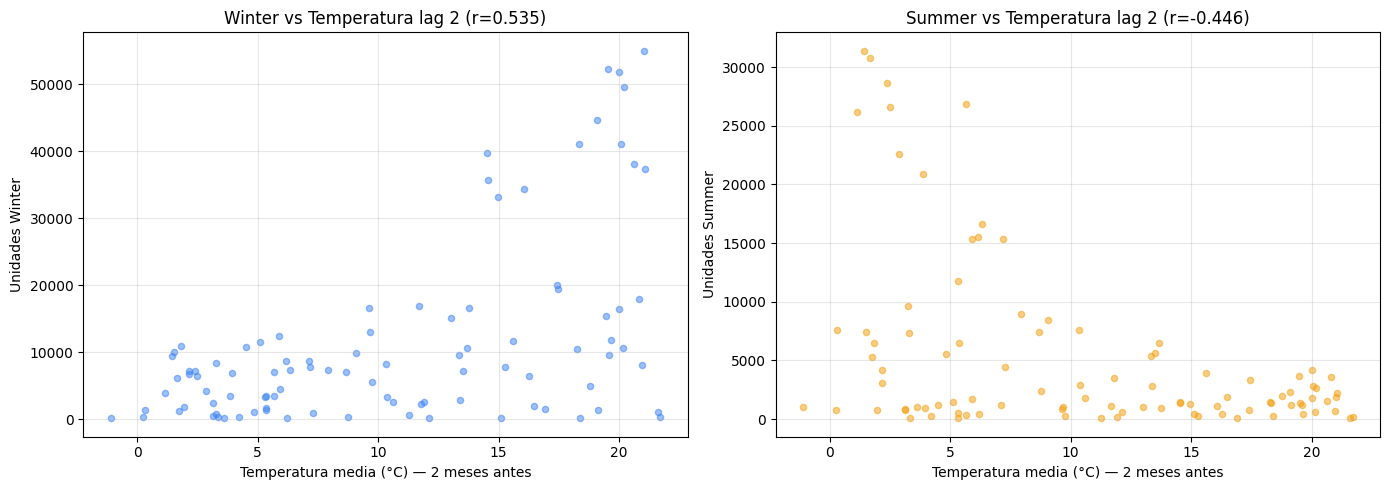

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

temp_lag2 = df_merged['temp_media'].shift(2)
mask = temp_lag2.notna()

axes[0].scatter(temp_lag2[mask], df_merged['Winter'][mask], 
                color='#3B82F6', alpha=0.5, s=20)
axes[0].set_xlabel('Temperatura media (°C) — 2 meses antes')
axes[0].set_ylabel('Unidades Winter')
axes[0].set_title(f'Winter vs Temperatura lag 2 (r=0.535)')
axes[0].grid(True, alpha=0.3)

# Summer vs temperatura lag 2
axes[1].scatter(temp_lag2[mask], df_merged['Summer'][mask], 
                color='#F59E0B', alpha=0.5, s=20)
axes[1].set_xlabel('Temperatura media (°C) — 2 meses antes')
axes[1].set_ylabel('Unidades Summer')
axes[1].set_title(f'Summer vs Temperatura lag 2 (r=-0.446)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_correlacion_clima.png', dpi=150, bbox_inches='tight')
plt.show()

### Evolución del Ticket medio

##### Ticket medio por mes

In [33]:
si_ticket = df_si.groupby('MONTH_DT').agg(
    net_sales=('NET_SALES', 'sum'),
    billed_qty=('BILLED_QTY', 'sum')
).reset_index()

si_ticket['ticket_medio'] = si_ticket['net_sales'] / si_ticket['billed_qty']

print(si_ticket.head())

    MONTH_DT   net_sales  billed_qty  ticket_medio
0 2023-01-01  1302887.02     14968.0     87.044830
1 2023-02-01  3289833.31     41782.0     78.738053
2 2023-03-01  4198828.37     51473.0     81.573415
3 2023-04-01  2694894.53     30717.0     87.732999
4 2023-05-01  2413647.45     29016.0     83.183328


##### Evolución del ticket medio

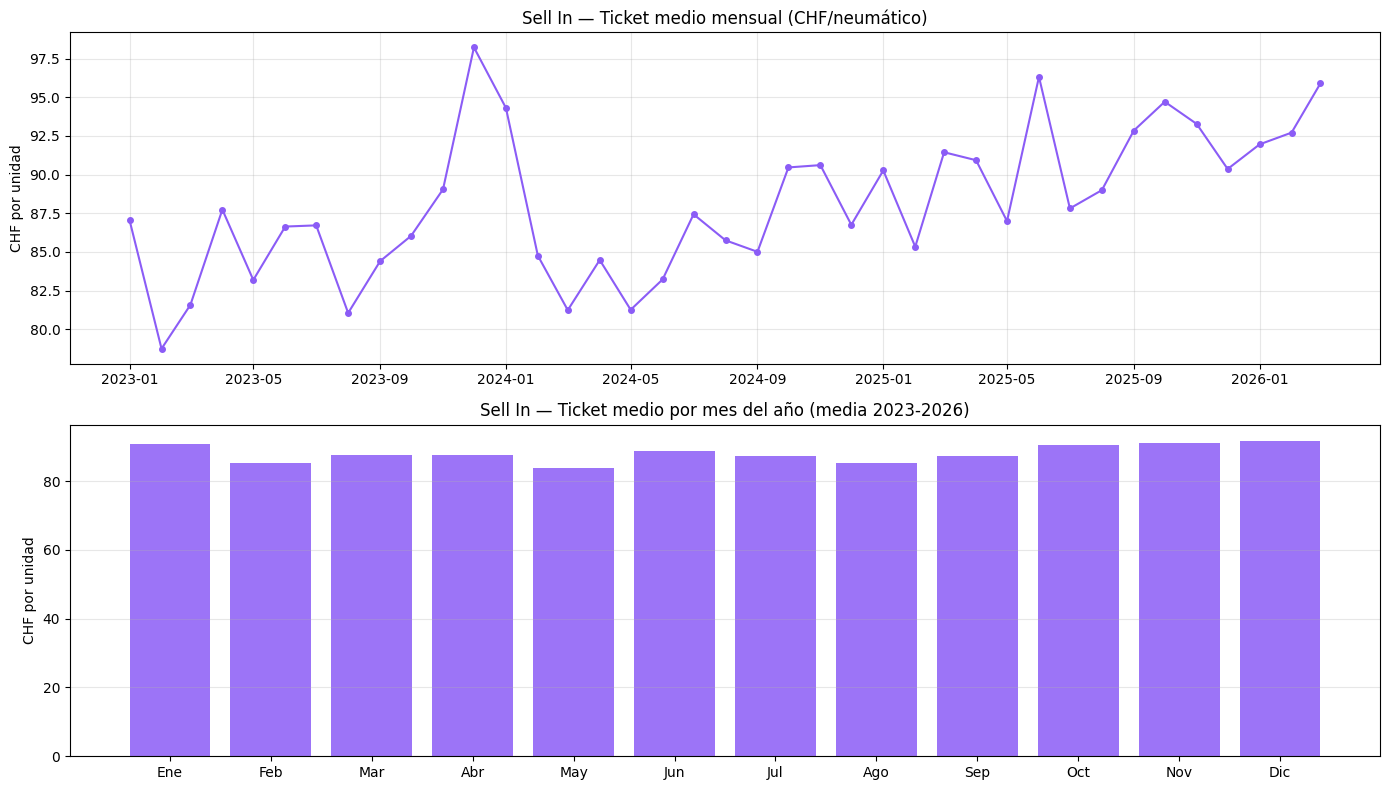

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(si_ticket['MONTH_DT'], si_ticket['ticket_medio'], 
             color='#8B5CF6', linewidth=1.5, marker='o', markersize=4)
axes[0].set_title('Sell In — Ticket medio mensual (CHF/neumático)')
axes[0].set_ylabel('CHF por unidad')
axes[0].grid(True, alpha=0.3)

si_ticket['mes'] = si_ticket['MONTH_DT'].dt.month
ticket_estacional = si_ticket.groupby('mes')['ticket_medio'].mean()

axes[1].bar(range(1,13), ticket_estacional, color='#8B5CF6', alpha=0.85)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                          'Jul','Ago','Sep','Oct','Nov','Dic'])
axes[1].set_title('Sell In — Ticket medio por mes del año (media 2023-2026)')
axes[1].set_ylabel('CHF por unidad')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('temporal_ticket_medio.png', dpi=150, bbox_inches='tight')
plt.show()

Se ve una tendencia alcista en el precio por unidad, lo que puede ser debido a la degradación monetaria sufrida en los últimos años, el pico de 2023 pudo deberse a alguna crisis de abastecimiento o algo similar (Crisis de suministros post-Covid/ Evergreen)

### Diferencias de flujo entre Sell-in y Sell-out

In [35]:
si_mensual = df_si.groupby('MONTH_DT')['BILLED_QTY'].sum().reset_index()
si_mensual.columns = ['fecha', 'sell_in']

so_mensual = df_so.groupby('MONTHDATE')['TOTALSELLOUTQTTY'].sum().reset_index()
so_mensual.columns = ['fecha', 'sell_out']

# Filtrar periodo común
fecha_inicio = '2023-01-01'
fecha_fin = '2026-02-01'

si_mensual = si_mensual[(si_mensual['fecha'] >= fecha_inicio) & 
                         (si_mensual['fecha'] <= fecha_fin)]
so_mensual = so_mensual[(so_mensual['fecha'] >= fecha_inicio) & 
                         (so_mensual['fecha'] <= fecha_fin)]

# Merge
df_gap = si_mensual.merge(so_mensual, on='fecha', how='inner')
df_gap['gap'] = df_gap['sell_in'] - df_gap['sell_out']
df_gap['gap_pct'] = (df_gap['gap'] / df_gap['sell_in']) * 100

print(df_gap.head(12))

        fecha  sell_in  sell_out      gap    gap_pct
0  2023-01-01  14968.0   11188.0   3780.0  25.253875
1  2023-02-01  41782.0   12238.0  29544.0  70.709875
2  2023-03-01  51473.0   35413.0  16060.0  31.200824
3  2023-04-01  30717.0   28891.0   1826.0   5.944591
4  2023-05-01  29016.0   25550.0   3466.0  11.945134
5  2023-06-01  25090.0   17917.0   7173.0  28.589079
6  2023-07-01  48966.0   14026.0  34940.0  71.355635
7  2023-08-01  53957.0   23033.0  30924.0  57.312304
8  2023-09-01  68032.0   47316.0  20716.0  30.450376
9  2023-10-01  65305.0   57678.0   7627.0  11.679044
10 2023-11-01  47614.0   46545.0   1069.0   2.245138
11 2023-12-01  17162.0   17895.0   -733.0  -4.271064


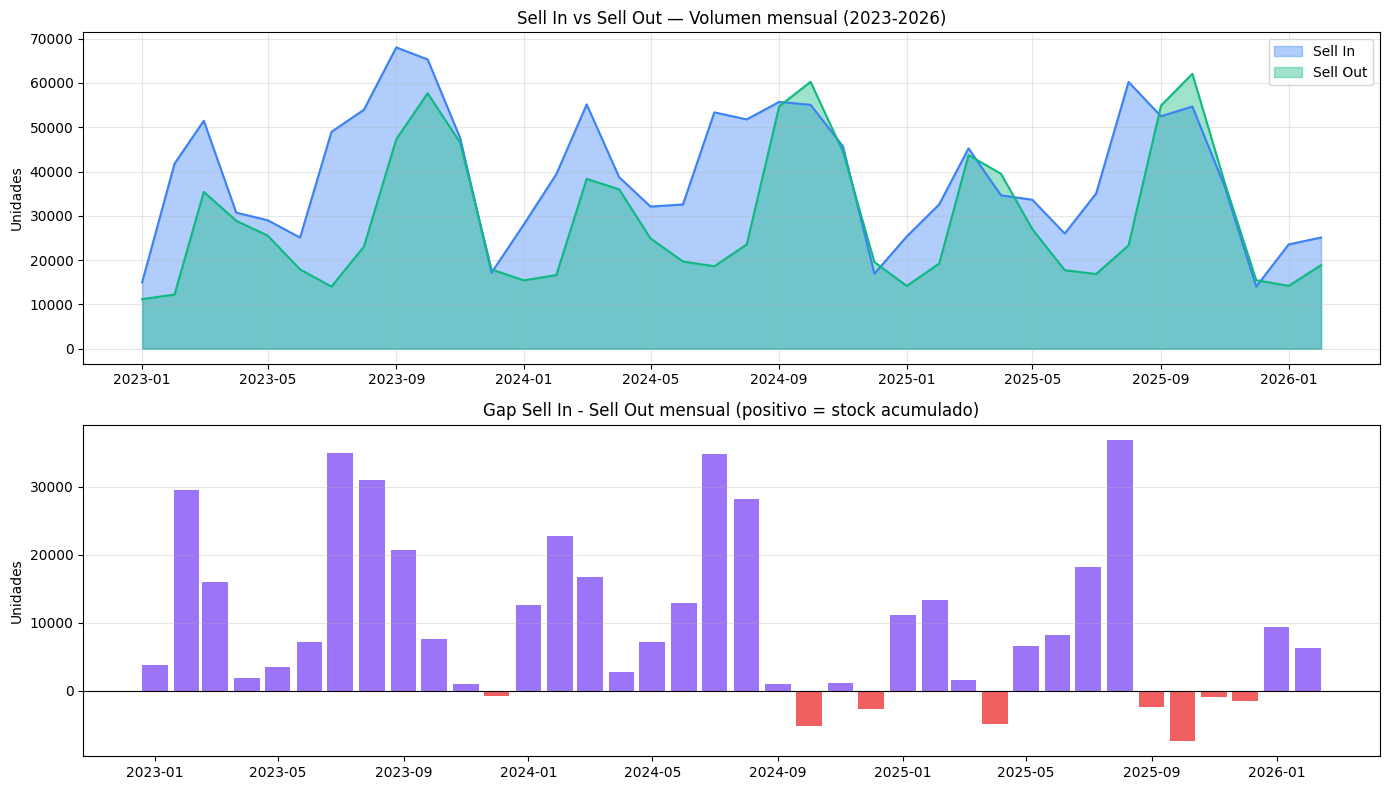


Gap medio mensual: 10093 unidades
Gap medio %: 24.1%
Meses con gap negativo: 8


In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].fill_between(df_gap['fecha'], df_gap['sell_in'], 
                      alpha=0.4, color='#3B82F6', label='Sell In')
axes[0].fill_between(df_gap['fecha'], df_gap['sell_out'], 
                      alpha=0.4, color='#10B981', label='Sell Out')
axes[0].plot(df_gap['fecha'], df_gap['sell_in'], color='#3B82F6', linewidth=1.5)
axes[0].plot(df_gap['fecha'], df_gap['sell_out'], color='#10B981', linewidth=1.5)
axes[0].set_title('Sell In vs Sell Out — Volumen mensual (2023-2026)')
axes[0].set_ylabel('Unidades')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

colores_gap = ['#EF4444' if g < 0 else '#8B5CF6' for g in df_gap['gap']]
axes[1].bar(df_gap['fecha'], df_gap['gap'], color=colores_gap, 
            alpha=0.85, width=25)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('Gap Sell In - Sell Out mensual (positivo = stock acumulado)')
axes[1].set_ylabel('Unidades')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('temporal_gap_sellin_sellout.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nGap medio mensual: {df_gap["gap"].mean():.0f} unidades')
print(f'Gap medio %: {df_gap["gap_pct"].mean():.1f}%')
print(f'Meses con gap negativo: {(df_gap["gap"] < 0).sum()}')

El gap negativo es una tendencia de ultimos años, además se puede ver que la demanda de sell in tienen  una lijera tendencia bajista. En cuanto a la importancia del gap negativo es casi inapreciable